In [139]:
import torch
import mlflow
import ast
import pandas as pd
import matplotlib.pyplot as plt
from mlflow.tracking import MlflowClient
import os 
import sys
project_root = os.path.expanduser("~/DLAM-Group6")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from external.xlstm_mixer.xlstm_mixer.models.xlstm_mixer import xLSTMMixer

In [140]:
client = MlflowClient()

df_runs = mlflow.search_runs(
    experiment_names=["single_chunk_forecast", "autoregressive_forecast"]
)

cutoff = pd.Timestamp("2026-09-02", tz="UTC")
summary_table = df_runs.query("(status=='FINISHED') & (start_time >= @cutoff)")#.sort_values(by="metrics.best_val_loss")

In [149]:
summary_table.sort_values(by="metrics.val_MSE_rescaled").loc[:, summary_table.columns.to_series().str.startswith("params.model")].head(5)

,params.model.hybrid,params.model.base_model_kwargs,params.model_kwargs.enc_in,params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size,params.model.model_kwargs.kwargs.xlstm_num_blocks,params.model.model_name,params.model.model_kwargs.seq_len,params.model.model_kwargs.pred_len,params.model.model_kwargs.kwargs.xlstm_num_heads,params.model.model_kwargs.kwargs.xlstm_dropout,params.model.prior_as_feature,params.model.base_model_kwargs.cutoff,params.model.prior,params.model.base_model_kwargs.trend,params.model.base_model_kwargs.seasonal_order,params.model.base_model_kwargs.exog_feature_names,params.model.base_model_kwargs.method,params.model.base_model_kwargs.order,params.model.model_kwargs.kwargs.xlstm_embedding_dim
63,False,None,23,None,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None
116,False,None,23,None,1,xLSTMMixer,720,4,16,0,None,None,None,None,None,None,None,None,None
40,False,None,23,None,2,xLSTMMixer,720,4,16,0,None,None,None,None,None,None,None,None,None
126,False,None,23,None,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None
28,False,None,23,None,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None


In [152]:
summary_table.query("`params.training.ar_steps`=='14'")["metrics.val_MSE_rescaled"]

6     12.743132
7     13.206060
26    12.686936
Name: metrics.val_MSE_rescaled, dtype: float64

In [110]:
def get_differing_params(
    df: pd.DataFrame,
    id_cols: list[str] = ["run_id", "tags.mlflow.runName", "experiment_id"],
    dropna_unique: bool = False,
) -> pd.DataFrame:

    if df.empty:
        return df

    param_cols = [c for c in df.columns if c.startswith("params.")]
    valid_id_cols = [c for c in id_cols if c in df.columns]

    differing_param_cols = []
    for col in param_cols:
        if df[col].nunique(dropna=dropna_unique) > 1:
            differing_param_cols.append(col)

    output_cols = valid_id_cols + differing_param_cols

    return df[output_cols]

def plot_subset(subset, param_of_interest):

    fix, axs = plt.subplots(1,2,figsize=(10, 3))

    for _, run in subset.iterrows():
        run_id = run["run_id"]
        run_name = run["tags.mlflow.runName"]
        run_mse = run["metrics.val_MSE_rescaled"]
        poi_value = run[param_of_interest]
        poi_name = param_of_interest.split(".")[-1]
        history_val = client.get_metric_history(run_id, "val_loss")
        steps_val = [m.step for m in history_val]
        values_val = [m.value for m in history_val]

        history_train = client.get_metric_history(run_id, "train_loss")
        steps_train = [m.step for m in history_train]
        values_train = [m.value for m in history_train]
        
        axs[0].plot(steps_val, values_val, label=f"{round(run_mse,2)}, {poi_name}={poi_value}")
        axs[1].plot(steps_train, values_train, label=f"{round(run_mse,2)}, {poi_name}={poi_value}")

        axs[0].set_xlabel("Epoch")
        axs[1].set_xlabel("Epoch")

        axs[0].set_ylabel("Validation Loss")
        axs[1].set_ylabel("Training Loss")

        axs[0].set_ylim(0.1,0.4)
        axs[1].set_ylim(0,0.4)

        axs[0].legend()
        axs[1].legend()

        axs[0].grid(True)
        axs[1].grid(True)

    return fix, axs

def find_comp_candidates(
    run_id: str,
    df: pd.DataFrame,
    param_column: str | None = None,
) -> pd.DataFrame:
    
    if "run_id" not in df.columns:
        raise ValueError("DataFrame must contain a 'run_id' column.")
    if "experiment_id" not in df.columns:
        raise ValueError("DataFrame must contain an 'experiment_id' column.")

    ref_rows = df[df["run_id"] == run_id]
    if len(ref_rows) == 0:
        raise ValueError(f"run_id '{run_id}' not found in dataframe.")
    if len(ref_rows) > 1:
        raise ValueError(f"run_id '{run_id}' appears multiple times in dataframe.")

    ref_row = ref_rows.iloc[0]

    # Only compare params.* columns
    param_cols = [c for c in df.columns if c.startswith("params.")]
    if not param_cols:
        raise ValueError("No columns starting with 'params.' found in dataframe.")

    if param_column is not None:
        if param_column not in param_cols:
            raise ValueError(
                f"Invalid param_column '{param_column}'. It must be one of: {param_cols}"
            )

    # Restrict to same experiment_id
    same_exp = df["experiment_id"] == ref_row["experiment_id"]

    # Compare params columns, treating NaN == NaN as equal
    def equal_with_nan(col):
        return (df[col] == ref_row[col]) | (df[col].isna() & pd.isna(ref_row[col]))

    if param_column is None:
        # Count how many params columns differ from reference
        equal_matrix = pd.DataFrame({col: equal_with_nan(col) for col in param_cols})
        num_different = (~equal_matrix).sum(axis=1)

        mask = same_exp & (num_different == 1)
    else:
        # Must differ in the chosen column...
        differs_target = ~equal_with_nan(param_column)

        # ...and match in all other params columns
        other_cols = [c for c in param_cols if c != param_column]
        if other_cols:
            equal_others = pd.DataFrame({col: equal_with_nan(col) for col in other_cols}).all(axis=1)
        else:
            equal_others = pd.Series(True, index=df.index)

        mask = same_exp & differs_target & equal_others

    # Usually you do not want to include the reference row itself;
    # it will not match anyway because it differs in 0 params columns.
    return df[mask].copy()

/tmp/ipykernel_2196225/2514120071.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])
/tmp/ipykernel_2196225/2514120071.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])


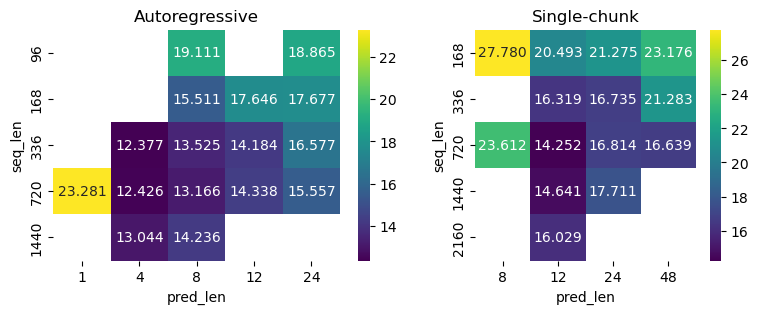

In [111]:
import seaborn as sns
subset_1 = summary_table.query("""experiment_id=='1' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.seed`=='11' &\
`params.shared.criterion`=='Huber'""")

subset_2 = summary_table.query("""experiment_id=='2' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber'""")

subset_1.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_1["params.shared.pred_len"])
subset_1.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_1["params.shared.seq_len"])
subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])

subset_2.loc[:,"params.shared.pred_len"] = pd.to_numeric(subset_2["params.shared.pred_len"])
subset_2.loc[:,"params.shared.seq_len"] = pd.to_numeric(subset_2["params.shared.seq_len"])
subset_2.loc[:,"MSE"] = pd.to_numeric(subset_2["metrics.val_MSE_rescaled"])

heatmap_df_1=subset_1.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')
heatmap_df_2=subset_2.pivot_table(columns='params.shared.pred_len', index='params.shared.seq_len', values='metrics.val_MSE_rescaled')

fig, axs = plt.subplots(1, 2, figsize=(9, 3), width_ratios=[1.3,1])
sns.heatmap(heatmap_df_1, annot=True, fmt=".3f", cmap="viridis", ax=axs[0])
axs[0].set_xlabel("pred_len")
axs[0].set_ylabel("seq_len")
axs[0].set_title("Autoregressive")

sns.heatmap(heatmap_df_2, annot=True, fmt=".3f", cmap="viridis", ax=axs[1])
axs[1].set_xlabel("pred_len")
axs[1].set_ylabel("seq_len")
axs[1].set_title("Single-chunk")
plt.show()

Windows seem to have a big impact on performance => finer search worth it before tuning other parameters

## Follow-up-1

### MSE vs Huber

(0.0, 0.8)

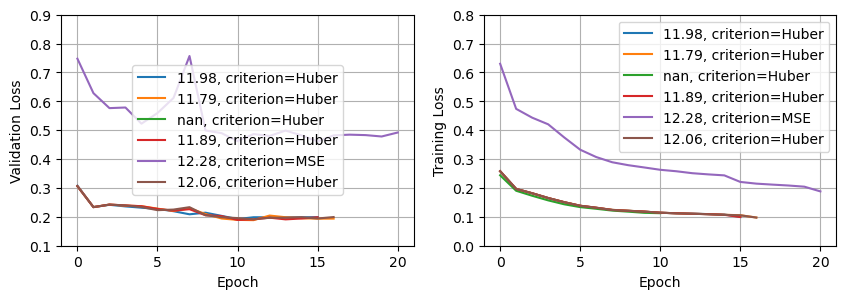

In [112]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`experiment_id`=='1' &\
`params.shared.pred_len`=='4' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
subset
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.shared.criterion")
axs[0].set_ylim(0.1, 0.9)
axs[1].set_ylim(0, 0.8)

### Learning rates

(0.0, 0.5)

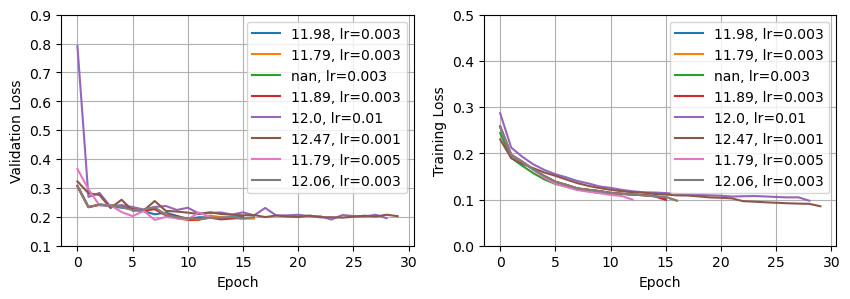

In [113]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.shared.criterion`=='Huber' &\
`params.training.loss_weighted`.isna() &\
`params.data.stride`=='12' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.optimizer_kwargs.lr")
axs[0].set_ylim(0.1, 0.9)
axs[1].set_ylim(0, 0.5)

Learning rate also has a bigger impact -> tune finely around 0.003

### Stride

(0.0, 0.5)

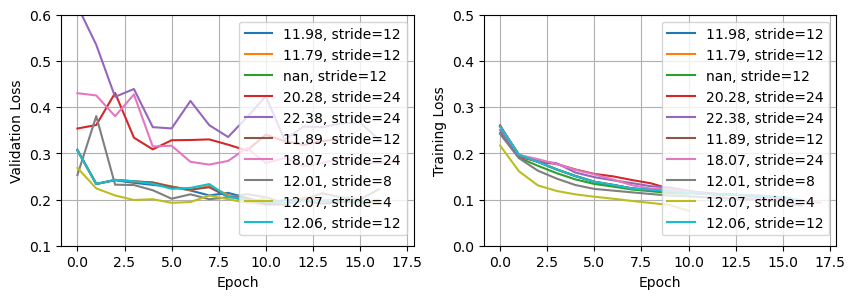

In [114]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.loss_weighted`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.data.stride")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

### Weighted loss

(0.0, 0.5)

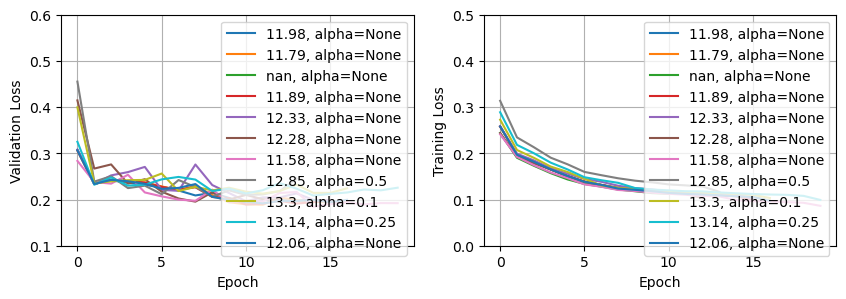

In [115]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.training.alpha")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

Advantage of $\alpha=0.5$ not entirely clear because validation loss is more noisy => try both for continuing

### Heads

(0.0, 0.5)

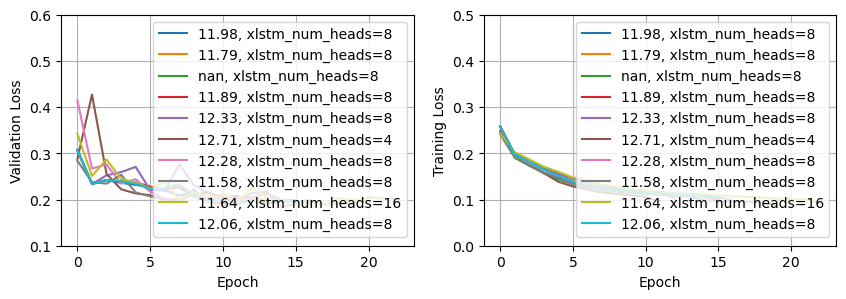

In [116]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_num_heads")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

4 heads could be worth trying as well, hard to tell benefit ebcause of noise and early stopping

## Num blocks

(0.0, 0.5)

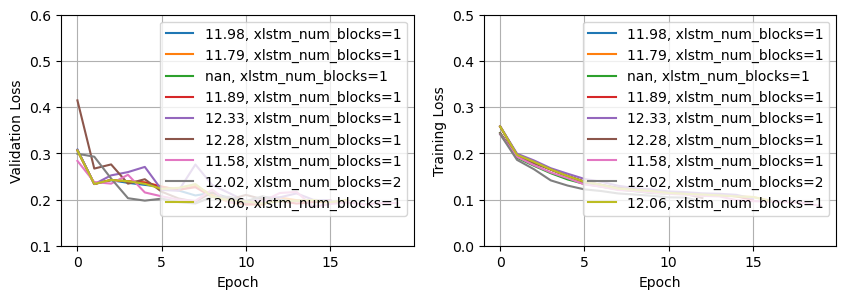

In [117]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.add_trailing_stats`.isna()""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_num_blocks")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

## Embedding dim

(0.0, 0.5)

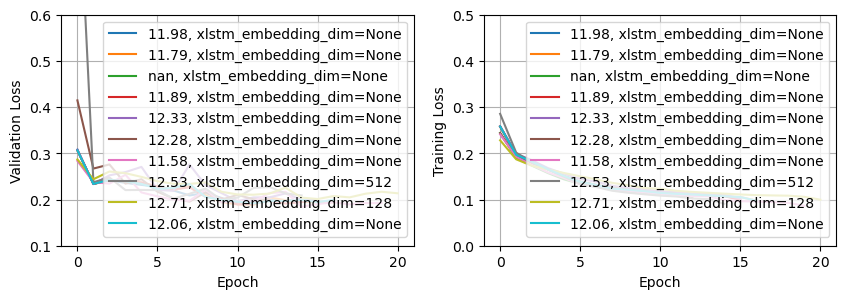

In [118]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.data.add_trailing_stats`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1'""")
#paths=subset.loc[:,summary_table.columns.to_series().str.startswith("params.save_dir")]
#subset.loc[:,summary_table.columns.to_series().str.startswith("metrics.val_MSE_rescaled")]
fig, axs = plot_subset(subset, param_of_interest="params.model.model_kwargs.kwargs.xlstm_embedding_dim")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

(0.0, 0.5)

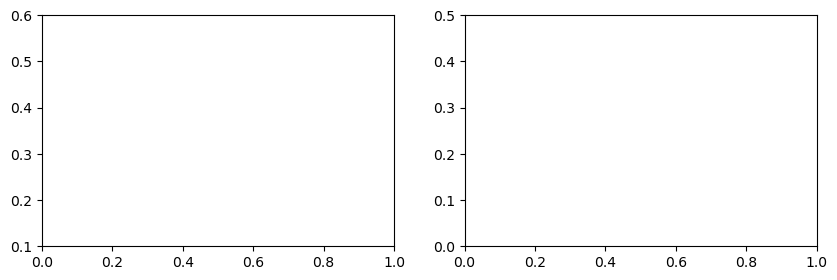

In [119]:
subset = summary_table.query("""`params.model.prior`=='Fourier'""")
fig, axs = plot_subset(subset, param_of_interest="params.model.base_model_kwargs.cutoff")
axs[0].set_ylim(0.1, 0.6)
axs[1].set_ylim(0, 0.5)

In [120]:
subset=summary_table.query("""experiment_id=='1' & `params.data.add_trailing_stats`=='True'""")
subset.loc[:,subset.columns.to_series().str.startswith("params.training")]

,params.training.optimizer_kwargs.weight_decay,params.training.min_epochs,params.training.criterion,params.training.ar_steps,params.training.grad_acc_steps,params.training.batch_size,params.training.optimizer,params.training.optimizer_kwargs.lr,params.training.grad_acc,params.training.loss_on,params.training.loss_weighted,params.training.mode,params.training.patience,params.training.max_epochs,params.training.num_epochs,params.training.milestones,params.training.alpha
8,0,5,Huber,4,None,128,Adam,0.003,None,target,None,autoregressive,5,100,None,None,None
35,0,5,MSE,4,None,128,Adam,0.003,None,target,None,autoregressive,5,100,None,None,None


In [121]:
subset = summary_table.query("""`params.shared.seq_len`=='336' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.model.prior`.isna() &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.seed`=='11' &\
`params.training.milestones`.isna()""")

In [122]:
get_differing_params(subset)

,run_id,tags.mlflow.runName,experiment_id
128,e8dded71598f43efac858d6b54eb4760,defiant-cod-146,1


In [123]:
run_id = "e8dded71598f43efac858d6b54eb4760"

history = client.get_metric_history(run_id, "val_loss")

val_losses = []
for m in history:
    print("step:", m.step, "value:", m.value)
    val_losses.append(m.value)

step: 0 value: 0.41351890563964844
step: 1 value: 0.3637140989303589
step: 2 value: 0.25132477283477783
step: 3 value: 0.2101147174835205
step: 4 value: 0.19836460053920746
step: 5 value: 0.2498263269662857
step: 6 value: 0.22682203352451324
step: 7 value: 0.21439163386821747
step: 8 value: 0.2469032108783722
step: 9 value: 0.21800938248634338


In [124]:
import numpy as np
np.argmin(val_losses)

np.int64(4)

## Follow-up 2

## Windows for 3 random seeds

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

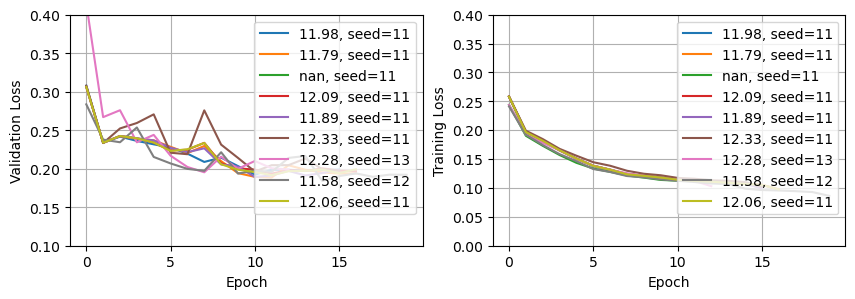

In [125]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='720' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber'""")
plot_subset(subset, param_of_interest='params.seed')

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

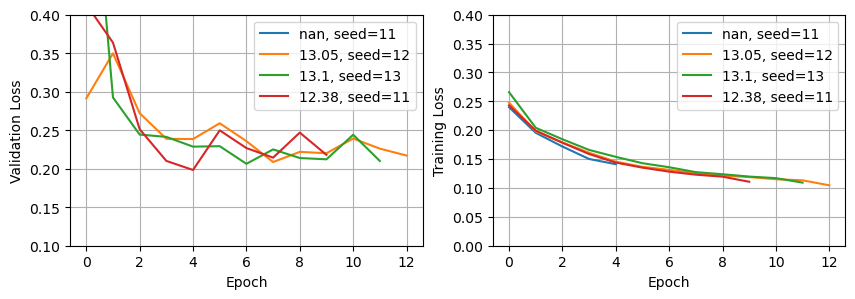

In [126]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='336' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber'""")
plot_subset(subset, param_of_interest='params.seed')

## Follow-up 3

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

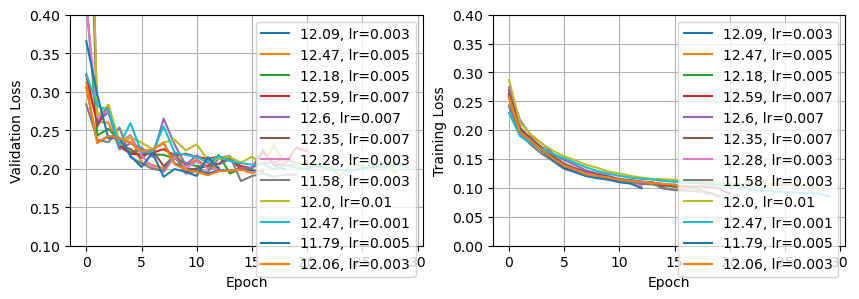

In [127]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='720' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.training.milestones`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_dropout`=='0'""") 
plot_subset(subset, param_of_interest='params.training.optimizer_kwargs.lr')

In [128]:
subset.groupby('params.training.optimizer_kwargs.lr')["metrics.val_MSE_rescaled"].mean()

params.training.optimizer_kwargs.lr
0.001    12.465446
0.003    12.001618
0.005    12.145418
0.007    12.516591
0.01     12.000575
Name: metrics.val_MSE_rescaled, dtype: float64

Stick to learning rate 0.003

### Dropout

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

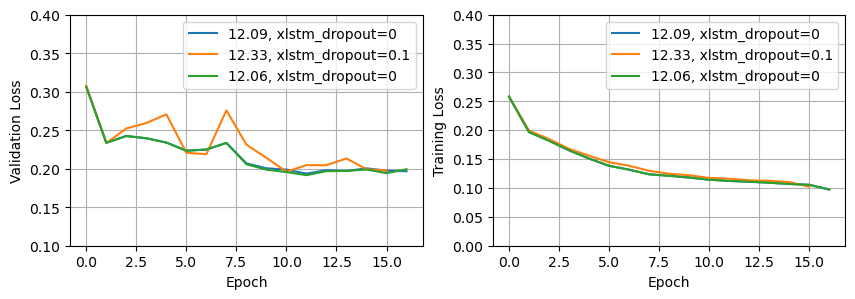

In [129]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='720' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.seed`=='11' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.training.milestones`.isna()""")
plot_subset(subset, param_of_interest='params.model.model_kwargs.kwargs.xlstm_dropout')

stick to no dropout

## Num Heads/num blocks

/tmp/ipykernel_2196225/3187175023.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])


Text(0.5, 1.0, 'Autoregressive')

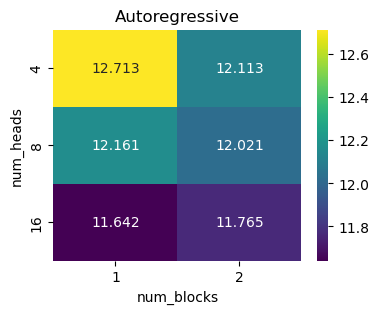

In [130]:
subset_1 = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='720' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.seed`=='11' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.training.milestones`.isna()""")


subset_1.loc[:,"params.model.model_kwargs.kwargs.xlstm_num_blocks"] = pd.to_numeric(subset_1["params.model.model_kwargs.kwargs.xlstm_num_blocks"])
subset_1.loc[:,"params.model.model_kwargs.kwargs.xlstm_num_heads"] = pd.to_numeric(subset_1["params.model.model_kwargs.kwargs.xlstm_num_heads"])
subset_1.loc[:,"MSE"] = pd.to_numeric(subset_1["metrics.val_MSE_rescaled"])


heatmap_df_1=subset_1.pivot_table(columns='params.model.model_kwargs.kwargs.xlstm_num_blocks', index='params.model.model_kwargs.kwargs.xlstm_num_heads', values='metrics.val_MSE_rescaled')

fig, axs = plt.subplots(1, 1, figsize=(4, 3))
sns.heatmap(heatmap_df_1, annot=True, fmt=".3f", cmap="viridis", ax=axs)
axs.set_xlabel("num_blocks")
axs.set_ylabel("num_heads")
axs.set_title("Autoregressive")


## Weight decay

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

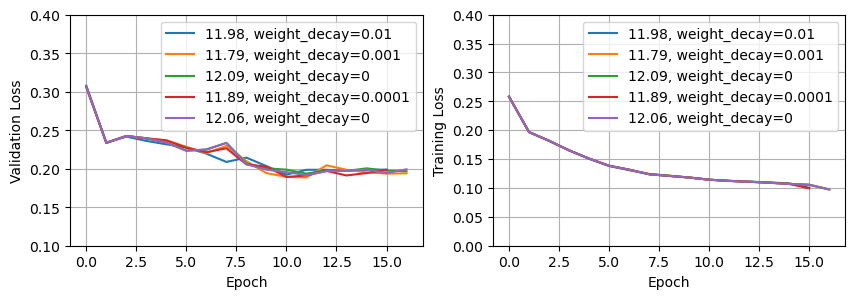

In [131]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='720' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.seed`=='11' &\
`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.training.milestones`.isna()""")
plot_subset(subset, param_of_interest='params.training.optimizer_kwargs.weight_decay')

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

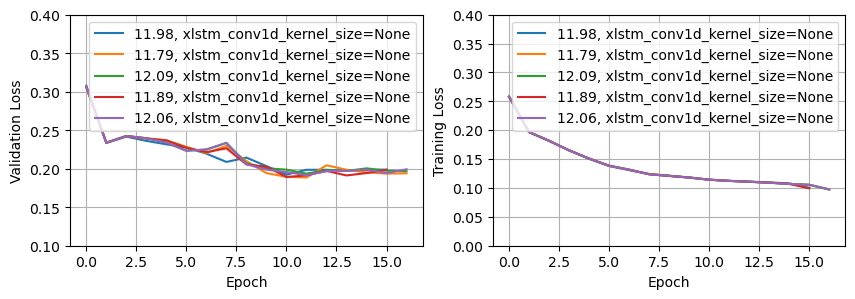

In [136]:
subset = summary_table.query("""experiment_id=='1' &\
`params.shared.pred_len`=='4' &\
`params.shared.seq_len`=='720' &\
`params.training.alpha`.isna() &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.data.stride`=='12' &\
`params.model.prior`.isna() &\
`params.shared.criterion`=='Huber' &\
`params.seed`=='11' &\
`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.training.milestones`.isna()""")
plot_subset(subset, param_of_interest='params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size')

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

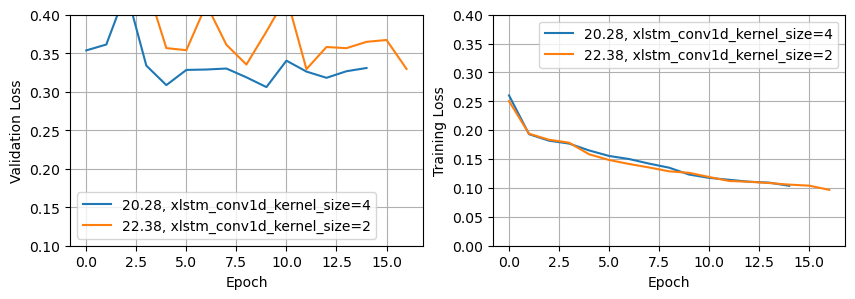

In [138]:
plot_subset(summary_table.query("~`params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size`.isna()"), param_of_interest='params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size')

### Summary stats

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

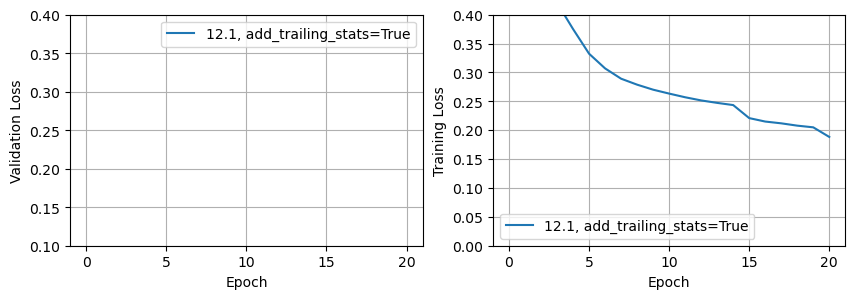

In [83]:
subset=summary_table.query("`params.data.add_trailing_stats`=='True'")
plot_subset(subset, param_of_interest='params.data.add_trailing_stats')

## ARIMA

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

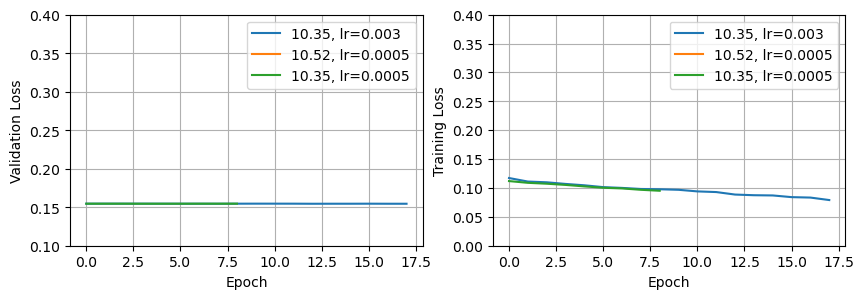

In [31]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='48' &\
`params.shared.criterion`=='Huber' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.seed`=='11' &\
`params.training.milestones`.isna()""")
plot_subset(subset, param_of_interest='params.training.optimizer_kwargs.lr')

## Fourier

In [97]:
subset = summary_table.query("""`params.shared.seq_len`=='720' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.seed`=='11' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.training.milestones`.isna()""")

In [98]:
subset["metrics.best_val_loss"]

9      0.193657
92     0.191613
93     0.207751
140    0.191613
Name: metrics.best_val_loss, dtype: float64

(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

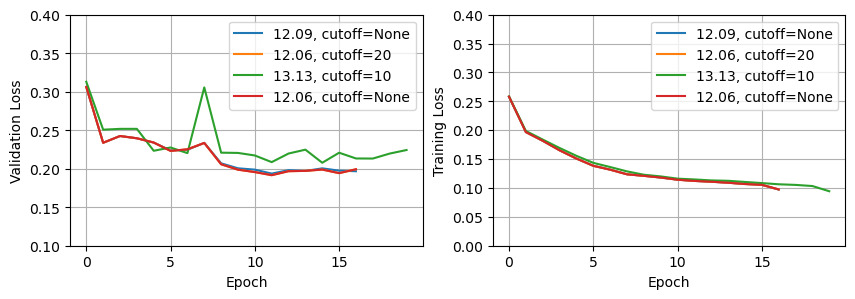

In [99]:
plot_subset(subset, param_of_interest='params.model.base_model_kwargs.cutoff')

In [29]:
subset = summary_table.query("""`params.shared.seq_len`=='336' &\
`params.shared.pred_len`=='4' &\
`experiment_id`=='1' &\
`params.data.stride`=='12' &\
`params.shared.criterion`=='Huber' &\
`params.training.alpha`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_num_heads`=='8' &\
`params.data.input`=='all' &\
`params.training.loss_on`=='target' &\
`params.model.model_kwargs.kwargs.xlstm_num_blocks`=='1' &\
`params.model.model_kwargs.kwargs.xlstm_embedding_dim`.isna() &\
`params.model.model_kwargs.kwargs.xlstm_dropout`=='0' &\
`params.seed`=='11' &\
`params.training.optimizer_kwargs.lr`=='0.003' &\
`params.training.optimizer_kwargs.weight_decay`=='0' &\
`params.training.milestones`.isna()""")

In [103]:
subset = summary_table.query("""`params.model.prior`.isna()&\
`experiment_id`=='1'""")
subset.sort_values(by="metrics.val_MSE_rescaled").loc[:,summary_table.columns.to_series().str.startswith("params.model")]

,params.model.hybrid,params.model_kwargs.enc_in,params.model.model_kwargs.kwargs.xlstm_num_blocks,params.model.model_name,params.model.model_kwargs.seq_len,params.model.model_kwargs.pred_len,params.model.model_kwargs.kwargs.xlstm_num_heads,params.model.model_kwargs.kwargs.xlstm_dropout,params.model.prior_as_feature,params.model.base_model_kwargs.cutoff,params.model.prior,params.model.base_model_kwargs.trend,params.model.base_model_kwargs.seasonal_order,params.model.base_model_kwargs.exog_feature_names,params.model.base_model_kwargs.method,params.model.base_model_kwargs.order,params.model.model_kwargs.kwargs.xlstm_conv1d_kernel_size,params.model.base_model_kwargs,params.model.model_kwargs.kwargs.xlstm_embedding_dim
45,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
102,False,23,1,xLSTMMixer,720,4,16,0,None,None,None,None,None,None,None,None,None,None,None
112,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
12,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
94,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
110,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
100,False,23,2,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
140,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
111,False,23,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None
9,False,25,1,xLSTMMixer,720,4,8,0,None,None,None,None,None,None,None,None,None,None,None


(<Figure size 1000x300 with 2 Axes>,
 array([<Axes: xlabel='Epoch', ylabel='Validation Loss'>,
        <Axes: xlabel='Epoch', ylabel='Training Loss'>], dtype=object))

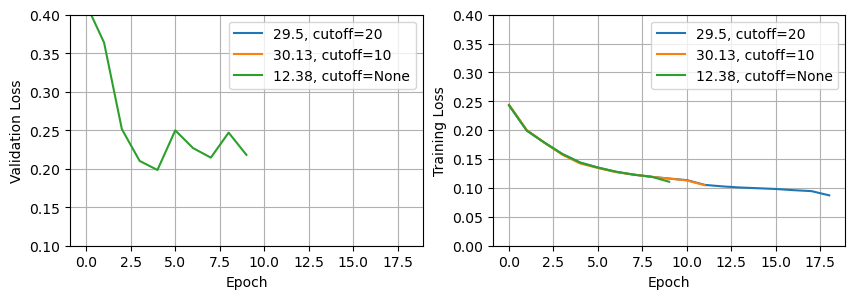

In [30]:
plot_subset(subset, param_of_interest='params.model.base_model_kwargs.cutoff')

### Kernel size

In [37]:
summary_table.query("~`params.training.milestones`.isna()")["params.shared.seq_len"].iloc[0]

'336'

In [90]:
subset=summary_table.query('~`params.training.milestones`.isna()')
get_differing_params(subset)["params.save_dir"].iloc[1]

'experiments/xLSTMMixer_c8875a04_93d32754ef464cf7b5191800d37ffc18'